In [7]:
import pandas as pd

teams = ['DET', 'CLE', 'NOP', 'WAS', 'PHI', 'CHI', 'UTA', 'CHO', 'IND',
       'DEN', 'NYK', 'SAS', 'DAL', 'LAC', 'MIN', 'MEM', 'ATL', 'MIA',
       'OKC', 'TOR', 'BRK', 'GSW', 'LAL', 'POR', 'PHO', 'SAC', 'HOU',
       'MIL', 'ORL', 'BOS']

def concat(teams):
    df = pd.DataFrame()
    for team in teams:
        df_team = pd.read_excel('queries_sec.xlsx', sheet_name=team).dropna()
        df_team['team'] = team
        df = pd.concat([df,df_team], axis=0)

    return df


df = concat(teams)

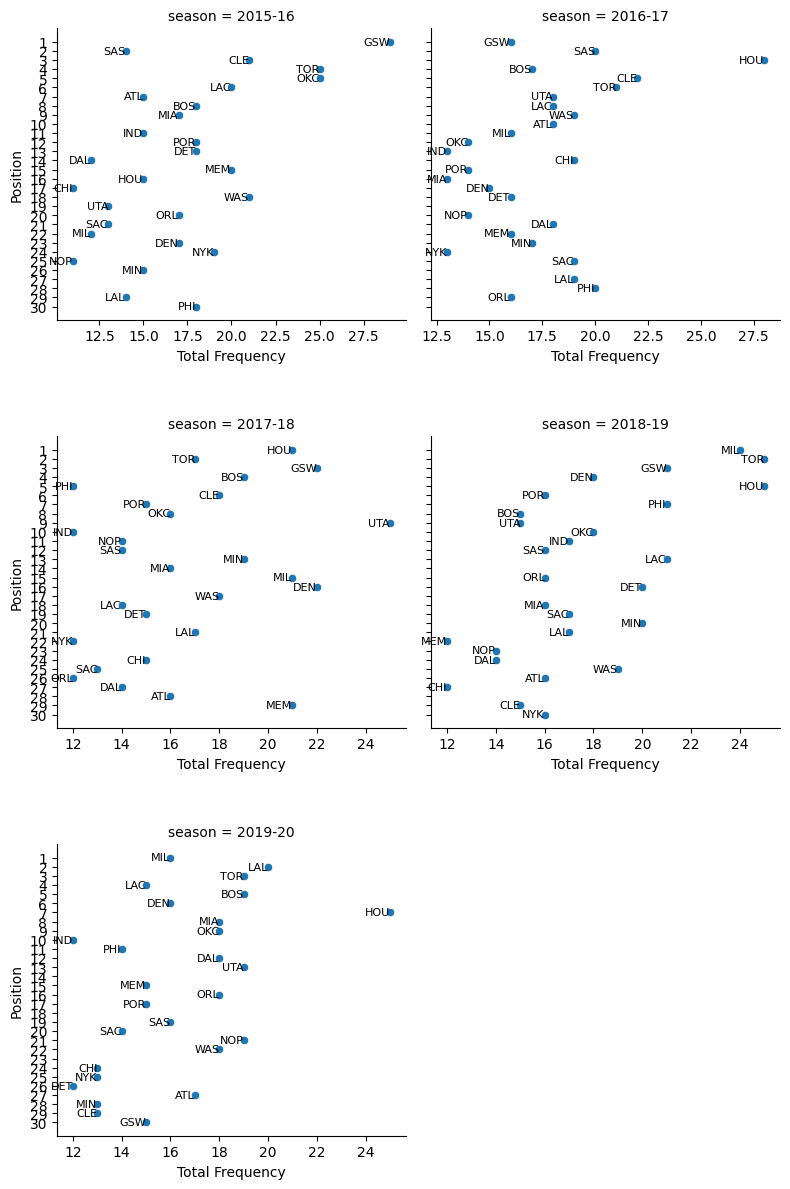

In [40]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List to store all season data
all_data = []

# Load standings data
standings_files = {
    "2015-16": "NBA_2015_16_Standings.csv",
    "2016-17": "NBA_2016-17_Standings.csv",
    "2017-18": "NBA_2017-18_Standings.csv",
    "2018-19": "NBA_2018-19_Standings.csv",
    "2019-20": "NBA_2019-20_Standings.csv"
}

# Read each standings file and merge it with df
for season, file in standings_files.items():
    standings = pd.read_csv('standings/'+file)
    standings.columns = ['team', 'pos']

    # Filter event 2 for the current season
    dff = df[(df.event == 2) & (df.season == season)]

    # Merge with standings
    dff = pd.merge(left=dff, right=standings, how='inner')

    # Add season column for FacetGrid
    dff["season"] = season

    # Store the processed data
    all_data.append(dff)

# Combine all seasons into one DataFrame
df_all_seasons = pd.concat(all_data)

# Create FacetGrid
g = sns.FacetGrid(df_all_seasons, col="season", col_wrap=2, height=4, sharex=False, sharey=True)
g.map_dataframe(sns.scatterplot, x="total_frequency", y="pos")

# Annotate points with team names
for ax, (season, data) in zip(g.axes.flat, df_all_seasons.groupby("season")):
    for i, row in data.iterrows():
        ax.text(row['total_frequency'], row['pos'], row['team'], fontsize=8, ha='right', va='center')

# Adjust y-axis and layout
for ax in g.axes.flat:
    ax.set_yticks(range(1, 31))
    ax.invert_yaxis()
    ax.set_ylabel("Position")
    ax.set_xlabel("Total Frequency")

plt.subplots_adjust(hspace=0.4)
plt.show()


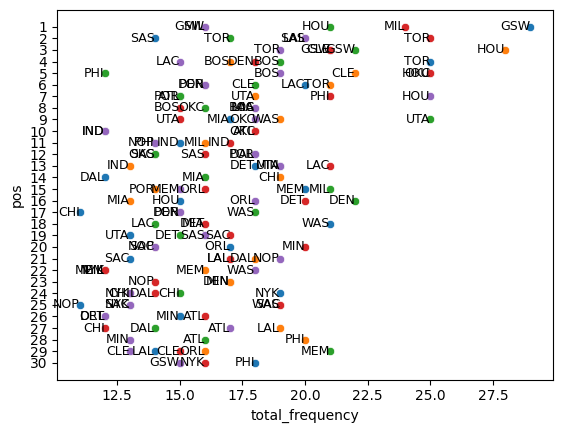

In [38]:
import os

seasons = []
for file in os.listdir('standings'):
    seasons.append(str(file))


for season, seas in zip(seasons,df.season.unique()):
    standings = pd.read_csv('standings/'+season)
    standings.columns = ['team','pos']

    dff = df[(df.event==2) & (df.season==seas)]

    dff = pd.merge(left=dff, right=standings, how='inner')

    sns.scatterplot(dff, x='total_frequency',y='pos')

    for i, row in dff.iterrows():
        plt.text(row['total_frequency'], row['pos'], row['team'], 
                fontsize=9, ha='right', va='center')
        
    plt.yticks([i for i in range(1,31)])
    plt.gca().invert_yaxis()

In [18]:
dff

,event,total_frequency,total_ratio,sequence,total_sec_frequency,total_sec_ratio,sec_sequence,season,team,standing
1,2,18,0.17495,"[{'Rebounder9': 'rebounder_same', 'ReboundType...",16,0.15575,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_o...",2015-16,DET,2
1,2,21,0.18400,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_o...",15,0.13315,"[{'Rebounder9': 'rebounder_same', 'ReboundType...",2015-16,CLE,2
1,2,11,0.11675,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_s...",11,0.11675,"[{'Rebounder9': 'rebounder_other', 'ReboundTyp...",2015-16,NOP,2
1,2,21,0.20580,"[{'Rebounder9': 'rebounder_other', 'ReboundTyp...",19,0.18630,"[{'Rebounder9': 'rebounder_other', 'ReboundTyp...",2015-16,WAS,2
1,2,18,0.16260,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_o...",14,0.12840,"[{'ShotDist9': '3pt', 'Shooter9': 'shooter_oth...",2015-16,PHI,2
1,2,11,0.13940,"[{'Rebounder9': 'rebounder_other', 'ReboundTyp...",10,0.12660,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_o...",2015-16,CHI,2
1,2,13,0.15850,"[{'FreeThrowShooter9': 'ft_other', 'Fouler10':...",11,0.13415,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_o...",2015-16,UTA,2
1,2,19,0.16460,"[{'Rebounder9': 'rebounder_same', 'ReboundType...",17,0.14460,"[{'ShotDist9': '3pt', 'Shooter9': 'shooter_oth...",2015-16,CHO,2
1,2,15,0.15480,"[{'ShotDist9': 'close', 'Shooter9': 'shooter_s...",13,0.13355,"[{'Rebounder9': 'rebounder_same', 'ReboundType...",2015-16,IND,2
1,2,17,0.17690,"[{'Rebounder9': 'rebounder_same', 'ReboundType...",13,0.13550,"[{'Rebounder9': 'rebounder_other', 'ReboundTyp...",2015-16,DEN,2


Text(0.5, 1.0, 'Frequency of most common sequence for last two events')

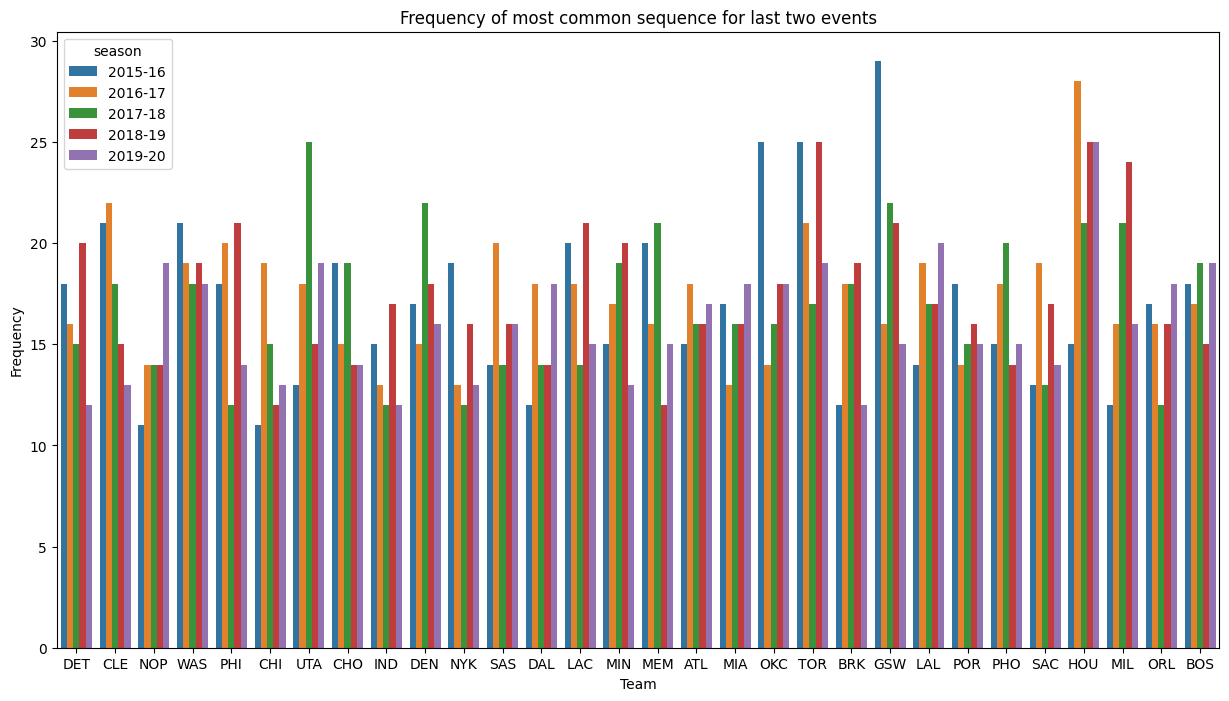

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.barplot(df[df.event == 2], x='team', y='total_frequency', hue='season')
plt.ylabel('Frequency')
plt.xlabel('Team')
plt.title('Frequency of most common sequence for last two events')

Text(0.5, 1.0, 'Frequency of most common sequence for last three events')

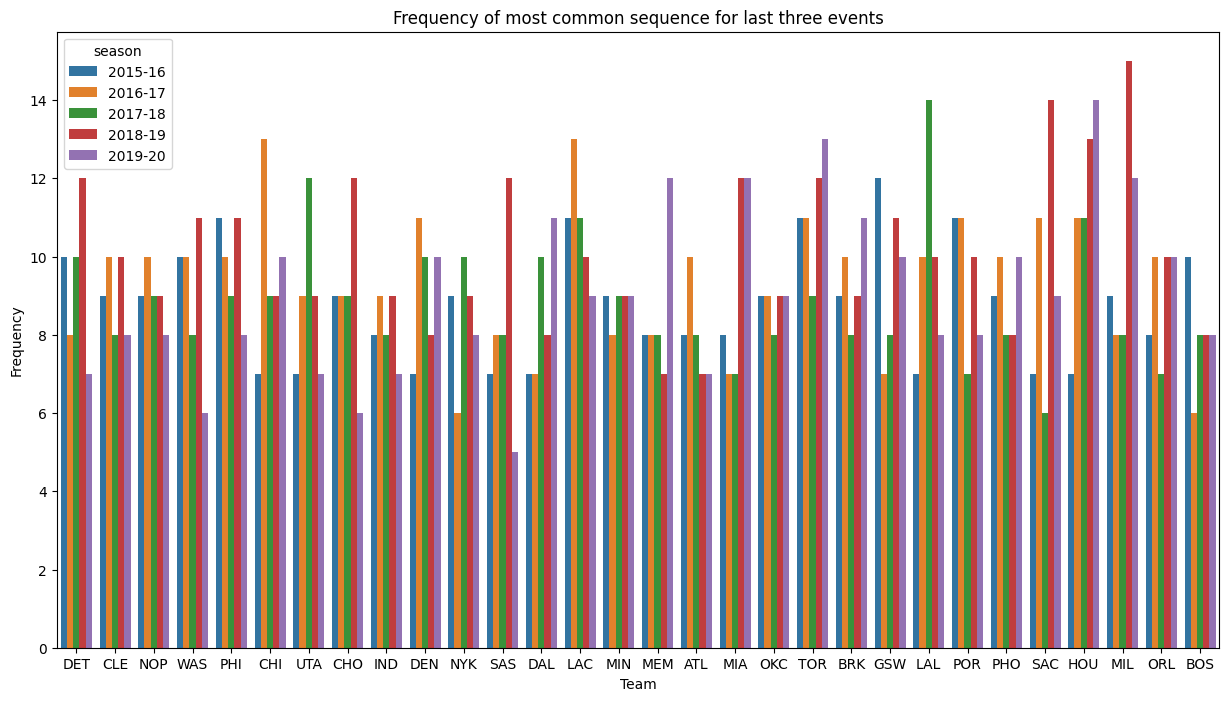

In [10]:
plt.figure(figsize=(15,8))
sns.barplot(df[df.event == 3], x='team', y='total_frequency', hue='season')
plt.ylabel('Frequency')
plt.xlabel('Team')
plt.title('Frequency of most common sequence for last three events')

Text(0.5, 1.0, 'Ratio of most common sequence versus all sequences for last two events')

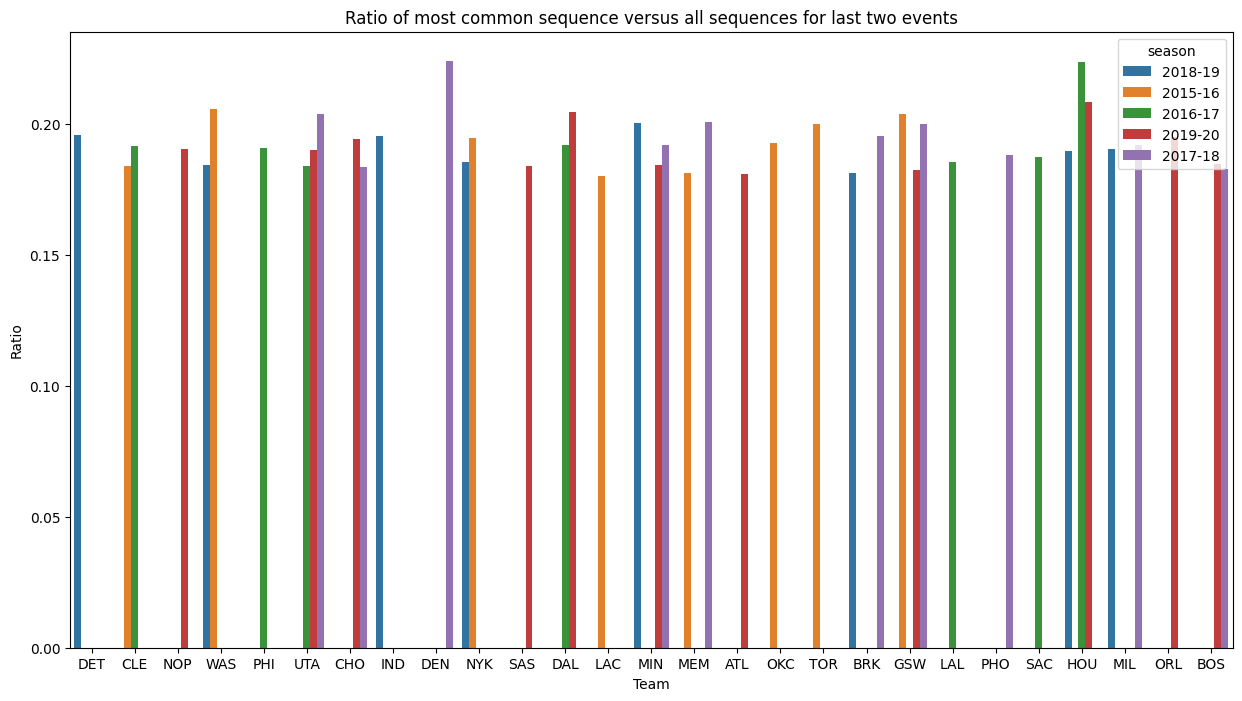

In [11]:
plt.figure(figsize=(15,8))
sns.barplot(df[(df.event == 2) & (df.total_ratio > df.total_ratio.quantile(0.6))], x='team', y='total_ratio', hue='season')
plt.ylabel('Ratio')
plt.xlabel('Team')
plt.title('Ratio of most common sequence versus all sequences for last two events')

Text(0.5, 1.0, 'Ratio of most common sequence versus all sequences for last three events')

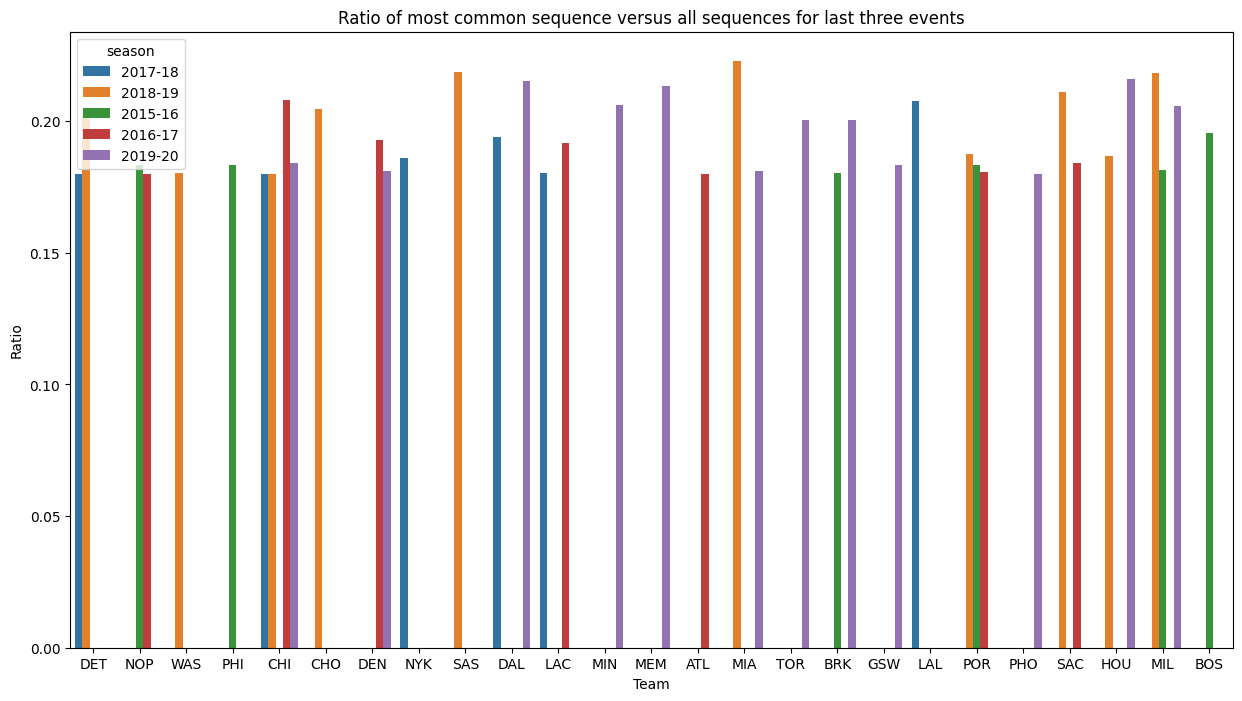

In [12]:
plt.figure(figsize=(15,8))
sns.barplot(df[(df.event == 3) & (df.total_ratio > df.total_ratio.quantile(0.6))], x='team', y='total_ratio', hue='season')
plt.ylabel('Ratio')
plt.xlabel('Team')
plt.title('Ratio of most common sequence versus all sequences for last three events')